In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install soundfile

import soundfile as sf
import numpy as np

Mounted at /content/drive


In [2]:
import math, re, random
from pathlib import Path

import numpy as np
import soundfile as sf
from scipy.signal import resample_poly

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def load_wav_mono(path: Path, target_sr: int) -> torch.Tensor:
    """
    Loads wav using soundfile, converts to mono float32, resamples if needed.
    Returns torch tensor [N] float32 in [-1,1] approx.
    """
    y, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if y.ndim == 2:
        y = y.mean(axis=1)
    if sr != target_sr:
        g = math.gcd(sr, target_sr)
        up = target_sr // g
        down = sr // g
        y = resample_poly(y, up, down).astype(np.float32)
    mx = np.max(np.abs(y)) + 1e-8
    y = (y / mx).astype(np.float32)
    return torch.from_numpy(y)

def collect_pairs_structured(speech_root: Path, genders, input_cat: str):
    pairs = []
    missing = 0
    for gender in genders:
        in_dir = speech_root / gender / input_cat
        ref_dir = speech_root / gender / "REF"
        wavs = list(in_dir.rglob("*.wav"))
        for w in wavs:
            if input_cat.upper() == "MIC":
                ref_name = w.name.replace("mic_", "ref_").replace(".wav", ".f0")
            elif input_cat.upper() == "LAR":
                ref_name = w.name.replace("lar_", "ref_").replace(".wav", ".f0")
            else:
                raise ValueError("INPUT_CATEGORY must be 'MIC' or 'LAR'")
            r = ref_dir / w.parent.name / ref_name
            if r.exists():
                pairs.append((w, r))
            else:
                missing += 1
    print(f"Paired utterances: {len(pairs)} | Missing REF: {missing}")
    return pairs

def speaker_id_from_filename(wav_path: Path):
    m = re.search(r"_(F\d\d|M\d\d)_", wav_path.name, flags=re.IGNORECASE)
    return m.group(1).upper() if m else wav_path.parent.name.upper()

def load_ref_f0_ascii(f0_path: Path) -> np.ndarray:
    # PTDB f0 has 4 cols; col0 is f0 Hz (0 means unvoiced)
    arr = np.loadtxt(str(f0_path))
    return arr[:, 0].astype(np.float32)

def frame_signal_pienet(y_1d: torch.Tensor, winlen: int, hop: int) -> torch.Tensor:
    """
    PiENet-like convention:
    - pad winlen/2 on both ends
    - n_frames = ceil(original_length / hop)
    """
    assert y_1d.ndim == 1
    N = y_1d.numel()
    pad = winlen // 2
    y = F.pad(y_1d, (pad, pad))
    frames_all = y.unfold(0, winlen, hop)  # [~, winlen]
    n_frames = int(math.ceil(N / hop))
    return frames_all[:n_frames]


Device: cpu


In [3]:
class PiENetLike(nn.Module):
    def __init__(self,
                 winlen=512,
                 nbins=351,
                 residual_channels=128,
                 filter_width=5,
                 dilations=(1,2,4,8,1,2,4,8),
                 postnet_channels=256,
                 dropout=0.4):
        super().__init__()
        self.in_proj = nn.Conv1d(winlen, residual_channels, kernel_size=1)
        self.dropout = nn.Dropout(p=dropout)

        self.fg_convs = nn.ModuleList([
            nn.Conv1d(residual_channels, 2*residual_channels,
                      kernel_size=filter_width, dilation=d,
                      padding=(filter_width//2)*d)
            for d in dilations
        ])
        self.skip_convs = nn.ModuleList([
            nn.Conv1d(residual_channels, residual_channels, kernel_size=1)
            for _ in dilations
        ])
        self.out_convs = nn.ModuleList([
            nn.Conv1d(residual_channels, residual_channels, kernel_size=1)
            for _ in dilations
        ])

        self.post1 = nn.Conv1d(residual_channels, postnet_channels,
                               kernel_size=filter_width, padding=filter_width//2)
        self.post2 = nn.Conv1d(postnet_channels, nbins,
                               kernel_size=filter_width, padding=filter_width//2)

    def forward(self, frames_bt):
        # frames_bt: [B,T,winlen]
        x = frames_bt.transpose(1, 2)   # [B,winlen,T]
        x = self.dropout(x)
        r = torch.tanh(self.in_proj(x)) # [B,R,T]

        skips = []
        h = r
        for fg, sk, out in zip(self.fg_convs, self.skip_convs, self.out_convs):
            y = fg(h)                   # [B,2R,T]
            a, b = y.chunk(2, dim=1)
            y = torch.tanh(a) * torch.sigmoid(b)
            skips.append(sk(y))         # [B,R,T]
            h = out(y) + h              # residual

        s = torch.stack(skips, dim=0).sum(dim=0)  # [B,R,T]
        z = torch.relu(self.post1(s))
        logits = self.post2(z)          # [B,nbins,T]
        return logits.transpose(1, 2)   # [B,T,nbins]


In [20]:
from pathlib import Path
import torch
import numpy as np

CKPT_PATH = Path("/content/drive/MyDrive/PiENet_colab/models/pienetlike_mic_female_male_bins351_50to500.pt")
assert CKPT_PATH.exists(), f"Not found: {CKPT_PATH}"

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load(str(CKPT_PATH), map_location=device, weights_only=False)

F0_BINS  = np.asarray(ckpt["bins"], dtype=np.float32)
TARGET_SR = int(ckpt["target_sr"])
WINLEN = int(ckpt["winlen"])
HOP = int(ckpt["hop"])
NBINS = int(ckpt["nbins"])
F0_MIN = float(ckpt["f0_min"])
F0_MAX = float(ckpt["f0_max"])
INPUT_CATEGORY = ckpt.get("input_category", "MIC")
GENDERS = ckpt.get("genders", ["FEMALE", "MALE"])
HOP_SEC = HOP / TARGET_SR

print("Loaded:", CKPT_PATH.name)
print({"TARGET_SR": TARGET_SR, "WINLEN": WINLEN, "HOP": HOP, "NBINS": NBINS, "F0_MIN": F0_MIN, "F0_MAX": F0_MAX})


# Build model + load weights
model = PiENetLike(winlen=WINLEN, nbins=NBINS).to(device)
missing, unexpected = model.load_state_dict(ckpt["model_state"], strict=False)
print("load_state_dict missing:", missing)
print("load_state_dict unexpected:", unexpected)
model.eval()
print("Model loaded and set to eval()")


Loaded: pienetlike_mic_female_male_bins351_50to500.pt
{'TARGET_SR': 16000, 'WINLEN': 512, 'HOP': 160, 'NBINS': 351, 'F0_MIN': 50.0, 'F0_MAX': 500.0}
load_state_dict missing: []
load_state_dict unexpected: []
Model loaded and set to eval()


In [5]:
from pathlib import Path
import random, re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import math

DATA_ROOT = Path("/content/drive/MyDrive/PiENet_data")
SPEECH_ROOT = DATA_ROOT / "SPEECH DATA"

def collect_pairs_structured(speech_root: Path, genders, input_cat: str):
    pairs = []
    missing = 0
    for gender in genders:
        in_dir  = speech_root / gender / input_cat
        ref_dir = speech_root / gender / "REF"
        wavs = list(in_dir.rglob("*.wav"))
        for w in wavs:
            if input_cat.upper() == "MIC":
                ref_name = w.name.replace("mic_", "ref_").replace(".wav", ".f0")
            elif input_cat.upper() == "LAR":
                ref_name = w.name.replace("lar_", "ref_").replace(".wav", ".f0")
            else:
                raise ValueError("input_cat must be MIC or LAR")
            r = ref_dir / w.parent.name / ref_name
            if r.exists():
                pairs.append((w, r))
            else:
                missing += 1
    print(f"Paired utterances: {len(pairs)} | Missing REF: {missing}")
    return pairs

def speaker_id_from_filename(wav_path: Path):
    m = re.search(r"_(F\d\d|M\d\d)_", wav_path.name, flags=re.IGNORECASE)
    return m.group(1).upper() if m else wav_path.parent.name.upper()

pairs = collect_pairs_structured(SPEECH_ROOT, GENDERS, INPUT_CATEGORY)

# Speaker split
spk_to_items = {}
for w, r in pairs:
    spk = speaker_id_from_filename(w)
    spk_to_items.setdefault(spk, []).append((w, r))

speakers = sorted(spk_to_items.keys())
random.seed(0)
random.shuffle(speakers)

n = len(speakers)
train_spk = set(speakers[: int(0.8*n)])
val_spk   = set(speakers[int(0.8*n): int(0.9*n)])
test_spk  = set(speakers[int(0.9*n):])

train_pairs = [x for s in train_spk for x in spk_to_items[s]]
val_pairs   = [x for s in val_spk   for x in spk_to_items[s]]
test_pairs  = [x for s in test_spk  for x in spk_to_items[s]]

print("Speakers:", n)
print("Train/Val/Test utterances:", len(train_pairs), len(val_pairs), len(test_pairs))
print("Test speakers:", sorted(test_spk))

# framing and f0 loading
def load_ref_f0_ascii(f0_path: Path) -> np.ndarray:
    arr = np.loadtxt(str(f0_path))
    return arr[:, 0].astype(np.float32)

def frame_signal_pienet(y_1d: torch.Tensor, winlen: int, hop: int) -> torch.Tensor:
    N = y_1d.numel()
    pad = winlen // 2
    y = F.pad(y_1d, (pad, pad))
    frames_all = y.unfold(0, winlen, hop)
    n_frames = int(math.ceil(N / hop))
    return frames_all[:n_frames]

# map f0 -> nearest log-bin index (bin0=unvoiced)
def f0_to_class_idx(f0_hz: np.ndarray, bins: np.ndarray) -> np.ndarray:
    idx = np.zeros_like(f0_hz, dtype=np.int64)
    voiced = f0_hz > 0
    if np.any(voiced):
        diffs = np.abs(np.log(f0_hz[voiced, None] + 1e-8) - np.log(bins[None, 1:] + 1e-8))
        idx_voiced = 1 + np.argmin(diffs, axis=1)
        idx[voiced] = idx_voiced
    return idx

# Dataset (no augmentation for evaluation)
class PTDBPiENetEvalDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        wav_path, f0_path = self.pairs[idx]
        wav = load_wav_mono(wav_path, TARGET_SR)             # torch [N]
        frames = frame_signal_pienet(wav, WINLEN, HOP)       # [T,WINLEN]
        f0_ref = load_ref_f0_ascii(f0_path)                  # np [Tref]
        cls = f0_to_class_idx(f0_ref, F0_BINS)               # np [Tref]
        T = min(frames.shape[0], cls.shape[0])
        return frames[:T].float(), torch.from_numpy(cls[:T]).long(), torch.from_numpy(f0_ref[:T]).float(), str(wav_path)

def collate_batch(batch):
    frames, cls, f0_ref, names = zip(*batch)
    lengths = torch.tensor([x.shape[0] for x in frames], dtype=torch.long)
    T_max = int(lengths.max().item())

    frames_p = torch.zeros((len(batch), T_max, WINLEN), dtype=torch.float32)
    cls_p    = torch.full((len(batch), T_max), -100, dtype=torch.long)
    f0_p     = torch.zeros((len(batch), T_max), dtype=torch.float32)

    for i, (fr, cl, f0) in enumerate(zip(frames, cls, f0_ref)):
        T = fr.shape[0]
        frames_p[i, :T] = fr
        cls_p[i, :T] = cl
        f0_p[i, :T] = f0

    return frames_p, cls_p, f0_p, lengths, names

BATCH_SIZE = 8
val_loader  = DataLoader(PTDBPiENetEvalDataset(val_pairs),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_batch)
test_loader = DataLoader(PTDBPiENetEvalDataset(test_pairs), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_batch)

print("Loader OK. Example batch:", next(iter(test_loader))[0].shape)


Paired utterances: 4718 | Missing REF: 0
Speakers: 20
Train/Val/Test utterances: 3774 472 472
Test speakers: ['M03', 'M04']
Loader OK. Example batch: torch.Size([8, 794, 512])


In [8]:
import torch
from tqdm import tqdm
import numpy as np

def make_time_mask(lengths, T):
    idx = torch.arange(T, device=lengths.device)[None, :]
    return idx < lengths[:, None]

def cents_error(f0_pred, f0_ref, eps=1e-6):
    ratio = (f0_pred + eps) / (f0_ref + eps)
    return 1200.0 * torch.log2(ratio)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    bins_t = torch.from_numpy(F0_BINS).to(device)

    vde_list, mae_list, acc50_list = [], [], []

    for frames, cls, f0_ref, lengths, _ in tqdm(loader, desc="eval"):
        frames = frames.to(device)
        f0_ref = f0_ref.to(device)
        lengths = lengths.to(device)

        logits = model(frames)                   # [B,T,C]
        pred_idx = torch.argmax(logits, dim=-1)  # [B,T]

        B, T = pred_idx.shape
        tmask = make_time_mask(lengths, T)

        voiced_pred = pred_idx > 0
        voiced_ref  = f0_ref > 0

        vde = (voiced_pred[tmask] != voiced_ref[tmask]).float().mean()
        vde_list.append(vde.item())

        f0_pred = bins_t[pred_idx]
        both_voiced = tmask & voiced_pred & voiced_ref
        if both_voiced.any():
            ce = torch.abs(cents_error(f0_pred[both_voiced], f0_ref[both_voiced]))
            mae_list.append(ce.mean().item())
            acc50_list.append((ce < 50.0).float().mean().item())

    def mean(xs):
        return float(sum(xs)/len(xs)) if xs else float("nan")

    return {
        "VoicingErrorRate": mean(vde_list),
        "MAE_cents_voiced": mean(mae_list),
        "Accuracy_within_50cents": mean(acc50_list),
    }

print("VAL metrics :", evaluate(val_loader))
print("TEST metrics:", evaluate(test_loader))


eval: 100%|██████████| 59/59 [05:37<00:00,  5.72s/it]


VAL metrics : {'VoicingErrorRate': 0.05437770612159018, 'MAE_cents_voiced': 18.958011061458265, 'Accuracy_within_50cents': 0.9834175220990585}


eval: 100%|██████████| 59/59 [04:19<00:00,  4.40s/it]

TEST metrics: {'VoicingErrorRate': 0.05424255053749529, 'MAE_cents_voiced': 13.58192342014636, 'Accuracy_within_50cents': 0.9750952427670107}


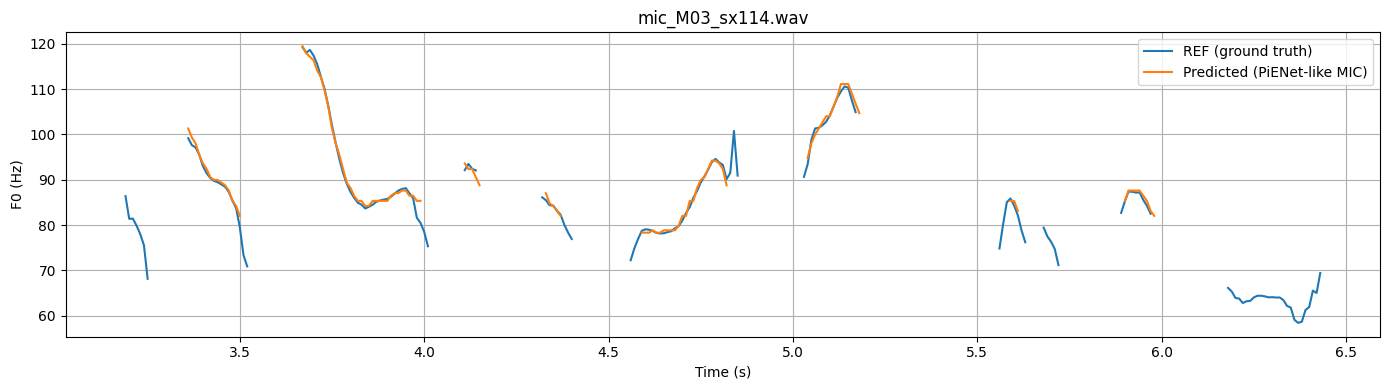

In [19]:
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def predict_f0_for_pair(wav_path: Path, ref_path: Path):
    wav = load_wav_mono(wav_path, TARGET_SR)
    frames = frame_signal_pienet(wav, WINLEN, HOP).unsqueeze(0).to(device)  # [1,T,WINLEN]

    logits = model(frames)[0]                 # [T,C]
    pred_idx = torch.argmax(logits, dim=-1).cpu().numpy()
    f0_pred = F0_BINS[pred_idx]

    f0_ref = load_ref_f0_ascii(ref_path)
    T = min(len(f0_pred), len(f0_ref))
    return f0_pred[:T], f0_ref[:T], wav_path.name

def plot_pred_vs_ref(idx=0):
    wav_path, ref_path = test_pairs[idx]
    f0_pred, f0_ref, name = predict_f0_for_pair(wav_path, ref_path)
    t = np.arange(len(f0_pred)) * (HOP / TARGET_SR)

    f0_pred_plot = f0_pred.astype(np.float32); f0_pred_plot[f0_pred_plot <= 0] = np.nan
    f0_ref_plot  = f0_ref.astype(np.float32);  f0_ref_plot[f0_ref_plot <= 0] = np.nan

    plt.figure(figsize=(14,4))
    plt.plot(t, f0_ref_plot, label="REF (ground truth)")
    plt.plot(t, f0_pred_plot, label="Predicted (PiENet-like MIC)")
    plt.xlabel("Time (s)")
    plt.ylabel("F0 (Hz)")
    plt.title(name)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pred_vs_ref(15)